### Cancer Prediction 

In [4]:
import numpy as np
import pandas as pd

In [6]:
file_path = "survey_lung_cancer.csv"

df = pd.read_csv(file_path)

In [9]:
## basic inspection
print("Data shape:", df.shape)

print("First 5 Rows in dataset:")
print(df.head())

Data shape: (309, 16)
First 5 Rows in dataset:
  GENDER  AGE  SMOKING  YELLOW_FINGERS  ANXIETY  PEER_PRESSURE  \
0      M   69        1               2        2              1   
1      M   74        2               1        1              1   
2      F   59        1               1        1              2   
3      M   63        2               2        2              1   
4      F   63        1               2        1              1   

   CHRONIC DISEASE  FATIGUE   ALLERGY   WHEEZING  ALCOHOL CONSUMING  COUGHING  \
0                1         2         1         2                  2         2   
1                2         2         2         1                  1         1   
2                1         2         1         2                  1         2   
3                1         1         1         1                  2         1   
4                1         1         1         2                  1         2   

   SHORTNESS OF BREATH  SWALLOWING DIFFICULTY  CHEST PAIN LUNG_CANCER

In [11]:
# check datatype
print("Dat types")
print(df.dtypes)

#missing valus
print("Missing values:")
print(df.isnull().sum())

print("Duplicates:", df.duplicated().sum())


Dat types
GENDER                     str
AGE                      int64
SMOKING                  int64
YELLOW_FINGERS           int64
ANXIETY                  int64
PEER_PRESSURE            int64
CHRONIC DISEASE          int64
FATIGUE                  int64
ALLERGY                  int64
WHEEZING                 int64
ALCOHOL CONSUMING        int64
COUGHING                 int64
SHORTNESS OF BREATH      int64
SWALLOWING DIFFICULTY    int64
CHEST PAIN               int64
LUNG_CANCER                str
dtype: object
Missing values:
GENDER                   0
AGE                      0
SMOKING                  0
YELLOW_FINGERS           0
ANXIETY                  0
PEER_PRESSURE            0
CHRONIC DISEASE          0
FATIGUE                  0
ALLERGY                  0
WHEEZING                 0
ALCOHOL CONSUMING        0
COUGHING                 0
SHORTNESS OF BREATH      0
SWALLOWING DIFFICULTY    0
CHEST PAIN               0
LUNG_CANCER              0
dtype: int64
Duplicates: 33


In [15]:
from sklearn.preprocessing import LabelEncoder

X = df.iloc[:, :-1].copy()
y = df.iloc[:, -1].copy()

print("Target column name:", df.columns[-1])
print("Target column unique values:")
print(y.astype(str).unique())

# correct head call
print(df.head())





Target column name: LUNG_CANCER
Target column unique values:
<StringArray>
['YES', 'NO']
Length: 2, dtype: str
  GENDER  AGE  SMOKING  YELLOW_FINGERS  ANXIETY  PEER_PRESSURE  \
0      M   69        1               2        2              1   
1      M   74        2               1        1              1   
2      F   59        1               1        1              2   
3      M   63        2               2        2              1   
4      F   63        1               2        1              1   

   CHRONIC DISEASE  FATIGUE   ALLERGY   WHEEZING  ALCOHOL CONSUMING  COUGHING  \
0                1         2         1         2                  2         2   
1                2         2         2         1                  1         1   
2                1         2         1         2                  1         2   
3                1         1         1         1                  2         1   
4                1         1         1         2                  1         2   

   SH

In [18]:
## cleaning column name
from sklearn.preprocessing import LabelEncoder

# cleaning column names
X.columns = X.columns.str.strip()

categorical_cols = X.select_dtypes(include=['object']).columns
print("Categorical columns:", list(categorical_cols))

# encoder dictionary
encoder = {}

# encode categorical columns
for col in categorical_cols:
    X[col] = X[col].astype(str).str.strip().str.lower()

    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

    # save encoder
    encoder[col] = le

print(X.head())
    


Categorical columns: ['GENDER']
   GENDER  AGE  SMOKING  YELLOW_FINGERS  ANXIETY  PEER_PRESSURE  \
0       1   69        1               2        2              1   
1       1   74        2               1        1              1   
2       0   59        1               1        1              2   
3       1   63        2               2        2              1   
4       0   63        1               2        1              1   

   CHRONIC DISEASE  FATIGUE  ALLERGY  WHEEZING  ALCOHOL CONSUMING  COUGHING  \
0                1        2        1         2                  2         2   
1                2        2        2         1                  1         1   
2                1        2        1         2                  1         2   
3                1        1        1         1                  2         1   
4                1        1        1         2                  1         2   

   SHORTNESS OF BREATH  SWALLOWING DIFFICULTY  CHEST PAIN  
0                    2        

C:\Users\ACER\AppData\Local\Temp\ipykernel_5204\2716671745.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object']).columns


In [20]:
##split the model into training and testimg dataset
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (247, 15)
X_test shape: (62, 15)
y_train shape: (247,)
y_test shape: (62,)


In [22]:
from sklearn.preprocessing import StandardScaler

# Feature scaling: z = (x - mean) / SD

# binary column(s) example
binary_cols = ["GENDER"]

# only select binary/numeric columns for scaling
numeric_cols = [col for col in X.columns if col in binary_cols]

# initialize scaler
scaler = StandardScaler()

# scale the selected columns
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

# check result
print(X.head())

     GENDER  AGE  SMOKING  YELLOW_FINGERS  ANXIETY  PEER_PRESSURE  \
0  0.952579   69        1               2        2              1   
1  0.952579   74        2               1        1              1   
2 -1.049781   59        1               1        1              2   
3  0.952579   63        2               2        2              1   
4 -1.049781   63        1               2        1              1   

   CHRONIC DISEASE  FATIGUE  ALLERGY  WHEEZING  ALCOHOL CONSUMING  COUGHING  \
0                1        2        1         2                  2         2   
1                2        2        2         1                  1         1   
2                1        2        1         2                  1         2   
3                1        1        1         1                  2         1   
4                1        1        1         2                  1         2   

   SHORTNESS OF BREATH  SWALLOWING DIFFICULTY  CHEST PAIN  
0                    2                      2     

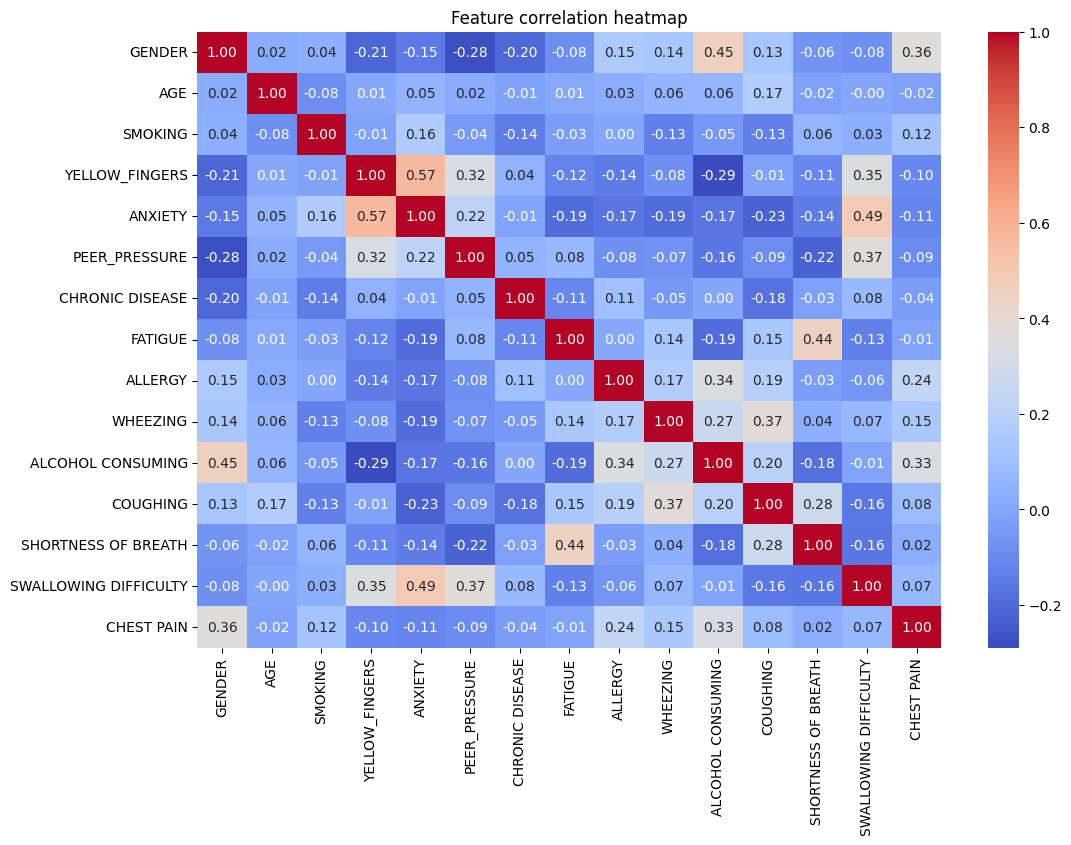

In [23]:
### visulization

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(X.corr(), annot = True, fmt= ".2f",cmap="coolwarm")
plt.title("Feature Correlation heatmap")
plt.show()

In [25]:
## training the model
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(
    n_estimators = 200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42

    
)
model.fit(X_train, y_train)
print("Model training sucessfully")


Model training sucessfully


In [28]:
### Evaluating the model

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
##predict
y_pred = model.predict(X_test)


##evaluation
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)
print("Accuracy:", accuracy)
print("Confusion Matrix:", cm)
print("Classification report:")
print(report)




Accuracy: 0.967741935483871
Confusion Matrix: [[ 1  1]
 [ 1 59]]
Classification report:
              precision    recall  f1-score   support

          NO       0.50      0.50      0.50         2
         YES       0.98      0.98      0.98        60

    accuracy                           0.97        62
   macro avg       0.74      0.74      0.74        62
weighted avg       0.97      0.97      0.97        62



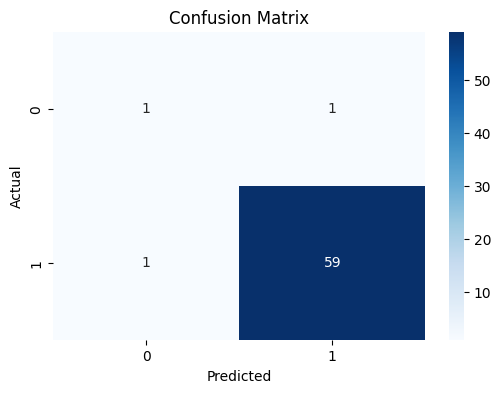

In [29]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt = "d", cmap ="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Confusion Matrix
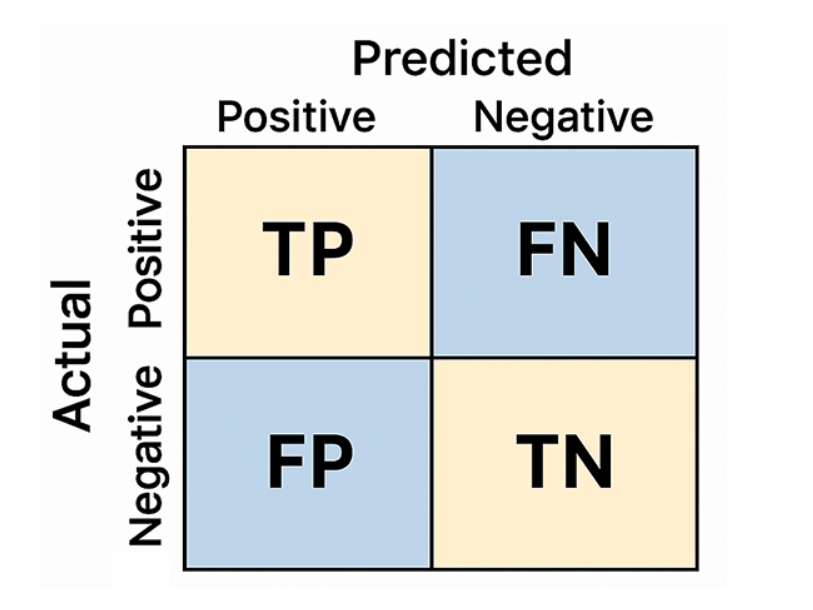

In [30]:
## feature importance

feature_importance= pd.DataFrame({
    "Features":X.columns,
    "Importance":model.feature_importances_
}).sort_values(by="Importance",ascending=True)

print(feature_importance)

                 Features  Importance
2                 SMOKING    0.036582
0                  GENDER    0.038780
12    SHORTNESS OF BREATH    0.040951
6         CHRONIC DISEASE    0.048110
14             CHEST PAIN    0.049690
9                WHEEZING    0.050829
4                 ANXIETY    0.052750
13  SWALLOWING DIFFICULTY    0.061063
7                 FATIGUE    0.061960
11               COUGHING    0.062539
3          YELLOW_FINGERS    0.067118
5           PEER_PRESSURE    0.069619
8                 ALLERGY    0.078249
10      ALCOHOL CONSUMING    0.089310
1                     AGE    0.192450


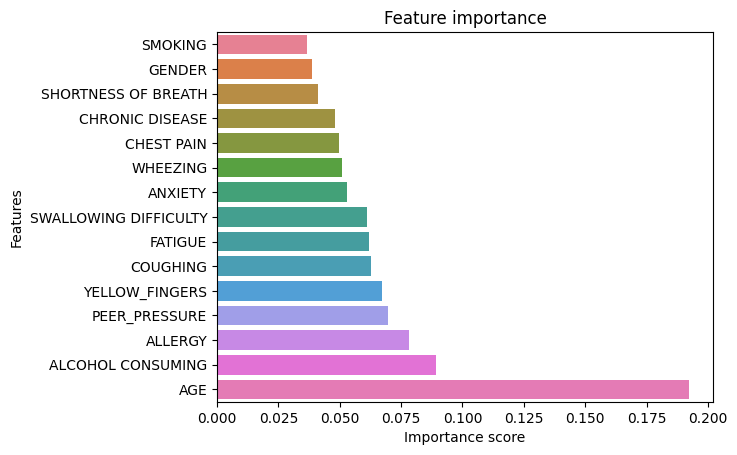

In [33]:
## bar chart

plt.Figure(figsize=(10,6))
sns.barplot(data=feature_importance,x="Importance",y="Features",hue="Features",legend=False)
plt.title("Feature importance")
plt.xlabel("Importance score")
plt.ylabel("Features")
plt.show()



In [35]:

import joblib


artifacts = {
    "model": model,
    "scaler": scaler,
    "label_encoder": encoder,    
    "feature_names": X.columns.tolist()
}

# save to disk
joblib.dump(artifacts, "lung_cancer.pkl")

['lung_cancer.pkl']